### Import Libraries

In [171]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sb 
import sklearn 
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix

### Load dataset 

In [173]:
data1 = pd.read_csv('calories.csv')

In [174]:
data1

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


### Info of Dataset

In [176]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


### head() - will print the first 5 rows and columns of the dataset 

In [178]:
data1.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


### tail(3) - will print the last 3 rows and columns of the dataset and as if do not give the value then by default it will print the last five rows and columns

In [180]:
data1.tail(3)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0
14999,11751526,male,63,173.0,79.0,18.0,92.0,40.5,98.0


### Checking the null values in the dataset 

In [182]:
data1.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

### Encoding Sex Column : Convert categorical values (male, female) into numerical form (0, 1) so the model can process them.

In [184]:
data1['Gender'] = data1['Gender'].map({'male': 0, 'female': 1})

In [185]:
data1

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,1,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,1,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,1,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,0,78,193.0,97.0,2.0,84.0,38.3,11.0


### Correlation Heatmap

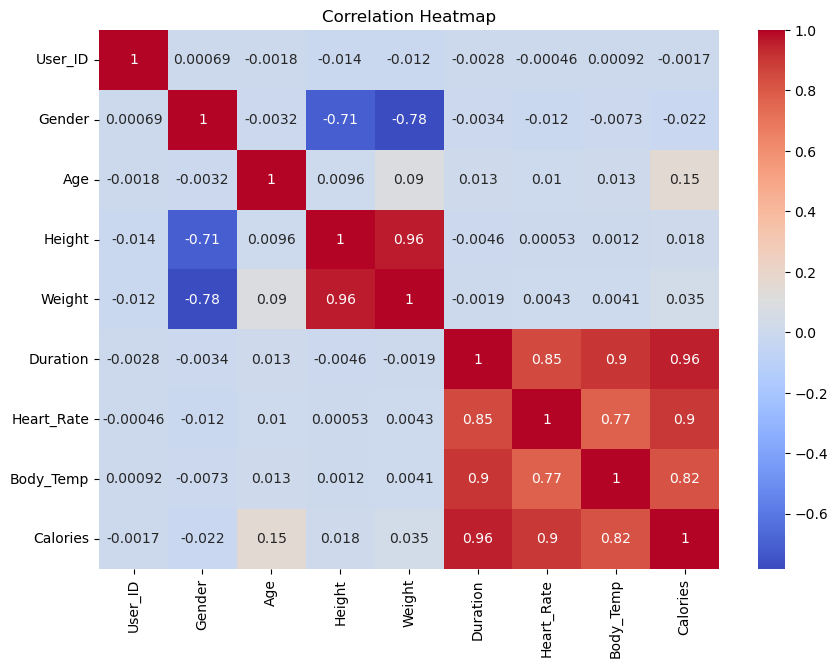

In [187]:
plt.figure(figsize=(10,7))
sb.heatmap(data1.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Calories Burnt vs Duration

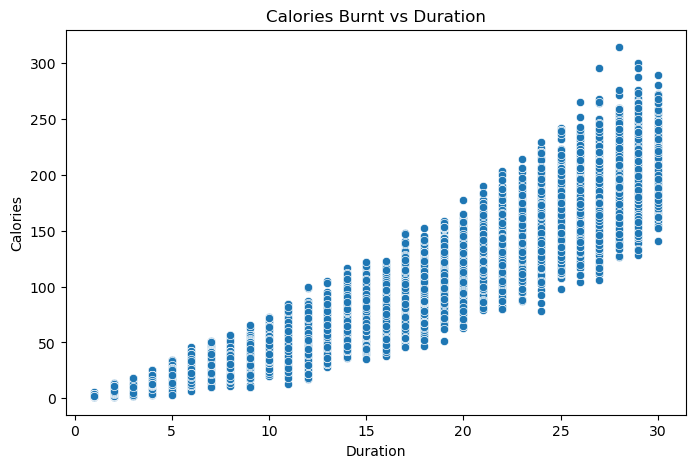

In [189]:
plt.figure(figsize=(8,5))
sb.scatterplot(x=data1['Duration'], y=data1['Calories'])
plt.title("Calories Burnt vs Duration")
plt.xlabel("Duration")
plt.ylabel("Calories")
plt.show()

### Distribution of Calories

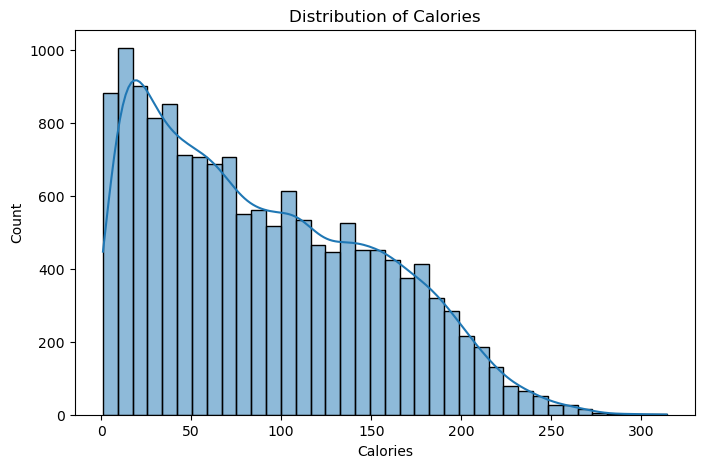

In [191]:
plt.figure(figsize=(8,5))
sb.histplot(data1['Calories'], kde=True)
plt.title("Distribution of Calories")
plt.show()

### Gender vs Calories Burnt

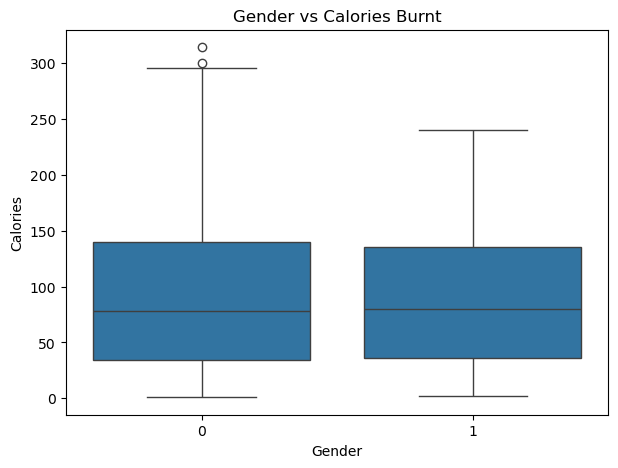

In [193]:
plt.figure(figsize=(7,5))
sb.boxplot(x=data1['Gender'], y=data1['Calories'])
plt.title("Gender vs Calories Burnt")
plt.show()

### Pairplot

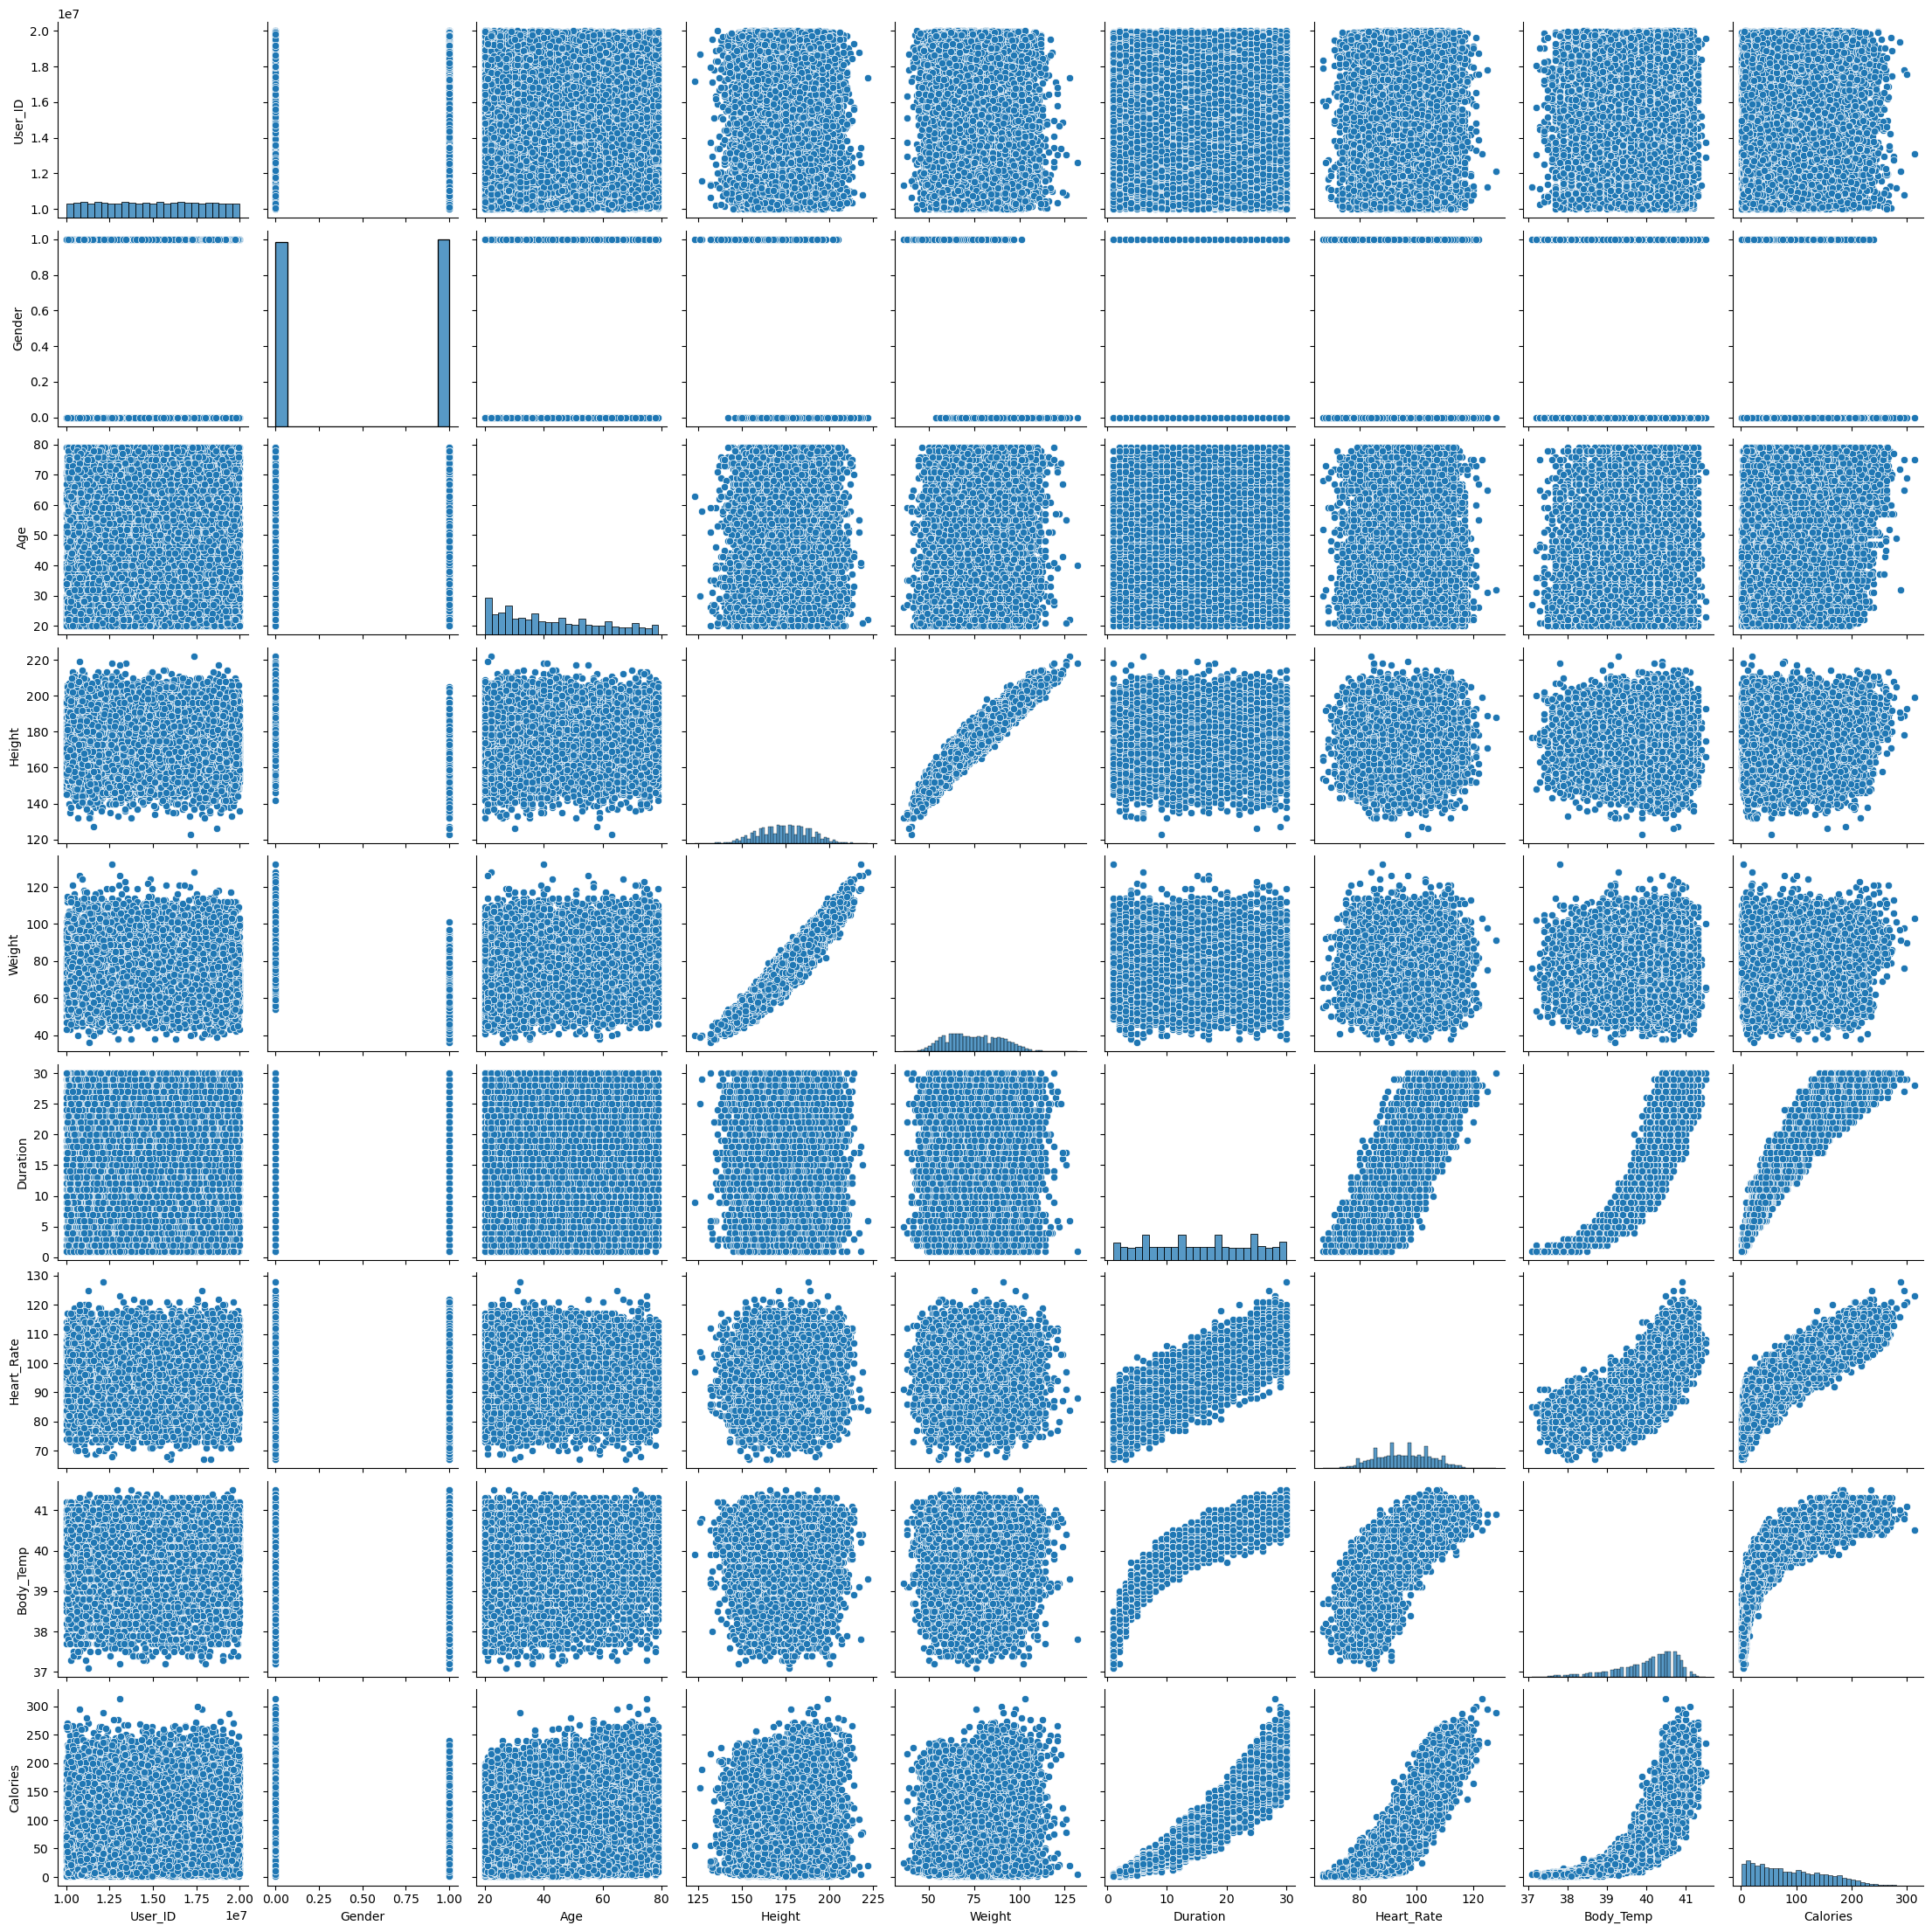

In [195]:
sb.pairplot(data1)
plt.show()

In [196]:
data1.head(1)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0


### Shape of the Dataset

In [198]:
data1.shape

(15000, 9)

### y contain the all targets of the dataset 

In [200]:
y = data1['Calories']

### Shape of Y

In [202]:
y.shape

(15000,)

### Values of the targets

In [204]:
y

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64

### First, we will drop the Targets from the dataset . Now, x contains the all features of the dataset 

In [206]:
x = data1.drop('Calories', axis=1)

### Shape of x

In [208]:
x.shape

(15000, 8)

### Value of the Features

In [210]:
x

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8
...,...,...,...,...,...,...,...,...
14995,15644082,1,20,193.0,86.0,11.0,92.0,40.4
14996,17212577,1,27,165.0,65.0,6.0,85.0,39.2
14997,17271188,1,43,159.0,58.0,16.0,90.0,40.1
14998,18643037,0,78,193.0,97.0,2.0,84.0,38.3


In [211]:
#scaler = StandardScaler()
#x_scaled = scaler.fit(x)

### The dataset is split into training (80%) and testing (20%) sets. The training set is used to train the model, while the testing set is used to evaluate its performance with Predicted data of the Model.

In [213]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

### Now, we apply feature scaling using StandardScaler to normalize the input features.

In [215]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) 

# Linear Regression 

### Creating the Model

In [218]:
model_lr = LinearRegression()

### Training the model with x_train and y_train

In [220]:
model_lr.fit(x_train, y_train)

LinearRegression()

### y_pred_lr contains the predicted value of the model which we get after Training the model with x_test

In [222]:
y_pred_lr = model_lr.predict(x_test)

In [223]:
y_pred_lr

array([170.53560015, 192.03435695,  56.27228884, ..., 129.45808131,
         2.67061356, 192.17371238])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [225]:
y_test

11499    173.0
6475     189.0
13167     53.0
862      161.0
5970     226.0
         ...  
6216     186.0
3585      53.0
10023    120.0
14044     20.0
12965    214.0
Name: Calories, Length: 3000, dtype: float64

### Evaluation Metrics of Linear Regression

In [227]:
print("EVALUATION METRICS OF LINEAR REGRESSION ")
print("Mean Absolute Error : ",mean_absolute_error(y_pred_lr, y_test))
print("Mean Squared Error : ",mean_squared_error(y_pred_lr, y_test))
print("r2 Score : ",r2_score(y_pred_lr, y_test))

EVALUATION METRICS OF LINEAR REGRESSION 
Mean Absolute Error :  8.443716322076584
Mean Squared Error :  132.06758234066442
r2 Score :  0.9657808596648955


# SVR

### Creating the Model

In [230]:
model_svr = SVR()

### Training the model with x_train and y_train

In [232]:
model_svr.fit(x_train, y_train)

SVR()

### y_pred_lr contains the predicted value of the model which we get after Training the model with x_test

In [234]:
y_pred_svr = model_svr.predict(x_test)

In [235]:
y_pred_svr

array([172.23962012, 180.16460868,  53.13581609, ..., 120.46557561,
        21.77972163, 193.9937085 ])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [237]:
y_test

11499    173.0
6475     189.0
13167     53.0
862      161.0
5970     226.0
         ...  
6216     186.0
3585      53.0
10023    120.0
14044     20.0
12965    214.0
Name: Calories, Length: 3000, dtype: float64

### Evaluation Metrics of Support Vector Regressor

In [239]:
print("EVALUATION METRICS OF SUPPORT VECTOR REGRESSOR")
print("Mean Absolute Error : ",mean_absolute_error(y_pred_svr, y_test))
print("Mean Square Error : ",mean_squared_error(y_pred_svr, y_test))
print("r2 Score : ",r2_score(y_pred_svr, y_test))

EVALUATION METRICS OF SUPPORT VECTOR REGRESSOR
Mean Absolute Error :  3.0318770626230744
Mean Square Error :  41.77781826716322
r2 Score :  0.9885754723373507


# Decision Tree

### Creating the Model

In [242]:
model_dt = DecisionTreeRegressor()

### Training the Model with x_train and y_train

In [244]:
model_dt.fit(x_train, y_train)

DecisionTreeRegressor()

### y_pred_dt contains the predicated values of the model which we got after training the model

In [246]:
y_pred_dt = model_dt.predict(x_test)

In [247]:
y_pred_dt

array([166., 204.,  52., ..., 114.,  19., 207.])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [249]:
y_test

11499    173.0
6475     189.0
13167     53.0
862      161.0
5970     226.0
         ...  
6216     186.0
3585      53.0
10023    120.0
14044     20.0
12965    214.0
Name: Calories, Length: 3000, dtype: float64

### Evaluation Metrics of Decision Tree

In [251]:
print("EVALUATION METRICS OF DECISION TREE")
print("Mean Absolute Error : ",mean_absolute_error(y_pred_dt, y_test))
print("Mean Square Error : ",mean_squared_error(y_pred_dt, y_test))
print("R2 Score : ",r2_score(y_pred_dt, y_test))

EVALUATION METRICS OF DECISION TREE
Mean Absolute Error :  3.6296666666666666
Mean Square Error :  31.625666666666667
R2 Score :  0.9921441119338036


# Random Forest

### Creating the Model

In [254]:
model_rf = RandomForestRegressor()

### Training the Model with x_train and y_train

In [256]:
model_rf.fit(x_train, y_train)

RandomForestRegressor()

### y_pred_rf contains the predicated values of the model which we get after training the model with x_test

In [258]:
y_pred_rf = model_rf.predict(x_test)

In [259]:
y_pred_rf

array([169.53, 194.21,  53.11, ..., 118.71,  19.59, 216.12])

### This displays the actual target values from the test dataset, which are used to compare with the predicted values.

In [261]:
y_test

11499    173.0
6475     189.0
13167     53.0
862      161.0
5970     226.0
         ...  
6216     186.0
3585      53.0
10023    120.0
14044     20.0
12965    214.0
Name: Calories, Length: 3000, dtype: float64

### Evaluation Metrics of Random Forest

In [263]:
print("EVALUTAION METRICS OF RANDOM FOREST")
print("Mean Absolute Error : ",mean_absolute_error(y_pred_rf, y_test))
print("Mean Square Error : ",mean_squared_error(y_pred_rf, y_test))
print("R2 Score : ",r2_score(y_pred_rf, y_test))

EVALUTAION METRICS OF RANDOM FOREST
Mean Absolute Error :  1.8168133333333336
Mean Square Error :  8.001837
R2 Score :  0.9979955470520757


# Conclusion

The Calories Burnt Prediction project was successfully implemented using multiple regression algorithms including Linear Regression, Support Vector Regressor, Decision Tree, and Random Forest Regressor. After comparing all models using evaluation metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score, the Random Forest Regressor achieved the best performance with the lowest error and highest accuracy.

The Random Forest model achieved an R² Score of approximately:

R2 Score = 0.9979

which indicates that the model predicts calories burnt with very high accuracy. The Actual vs Predicted Calories graph also showed that the predicted values closely follow the actual values, proving that the model generalizes well on the dataset.

Overall, this project demonstrates how machine learning can effectively predict calories burnt based on factors such as age, gender, height, weight, duration, heart rate, and body temperature.

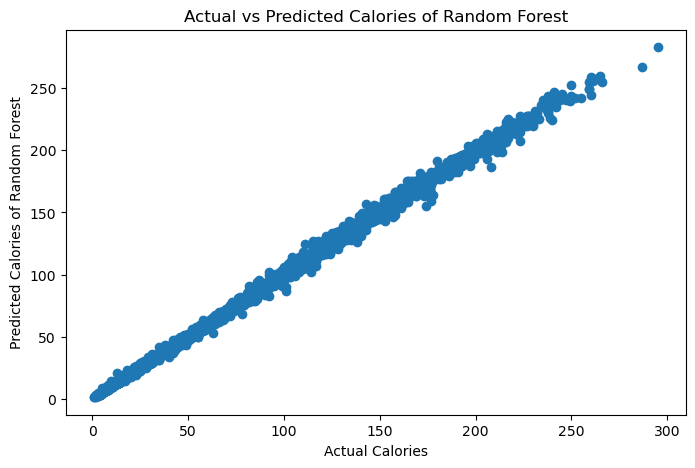

In [317]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories of Random Forest")
plt.title("Actual vs Predicted Calories of Random Forest")
plt.show()